<a href="https://colab.research.google.com/github/nurilhuda05/PCVK_Ganjil_2026/blob/main/P5_17_Muhammad_Nuril_Huda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====

import sys
import platform
import hashlib
import datetime
import zoneinfo

NAMA = 'Muhammad Nuril Huda'
NIM = '244107020004'
N = int(NIM[-3:])
PARAM = {
 'bins' : 2 ** ((N % 4) + 3),
 'clip' : round(1.0 + (N % 5) * 0.5, 1),
 'tile' : (N % 4) + 2,
 'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)

for k, v in PARAM.items():
 print('%-6s :' % k, v)

print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())

kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Muhammad Nuril Huda
NIM : 244107020004 | N = 4
bins   : 8
clip   : 3.0
tile   : 2
L      : 4
WAKTU : 2026-09-23 08:19:37 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 88415d37150ca5ff


# **E-1 PERCOBAAN HISTOGRAM**

**Menghubungkan Ke Drive**

In [3]:
from google.colab import drive

drive.mount('/content/drive')

CONTOH = '/content/drive/MyDrive/Semester 5/PCVK/images'
BASE = '/content/drive/MyDrive/Semester 5/PCVK/images/' + NIM

Mounted at /content/drive


**Import Library**

In [4]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

**Membuat Histogram Dari Gambar Contoh**

<BarContainer object of 256 artists>

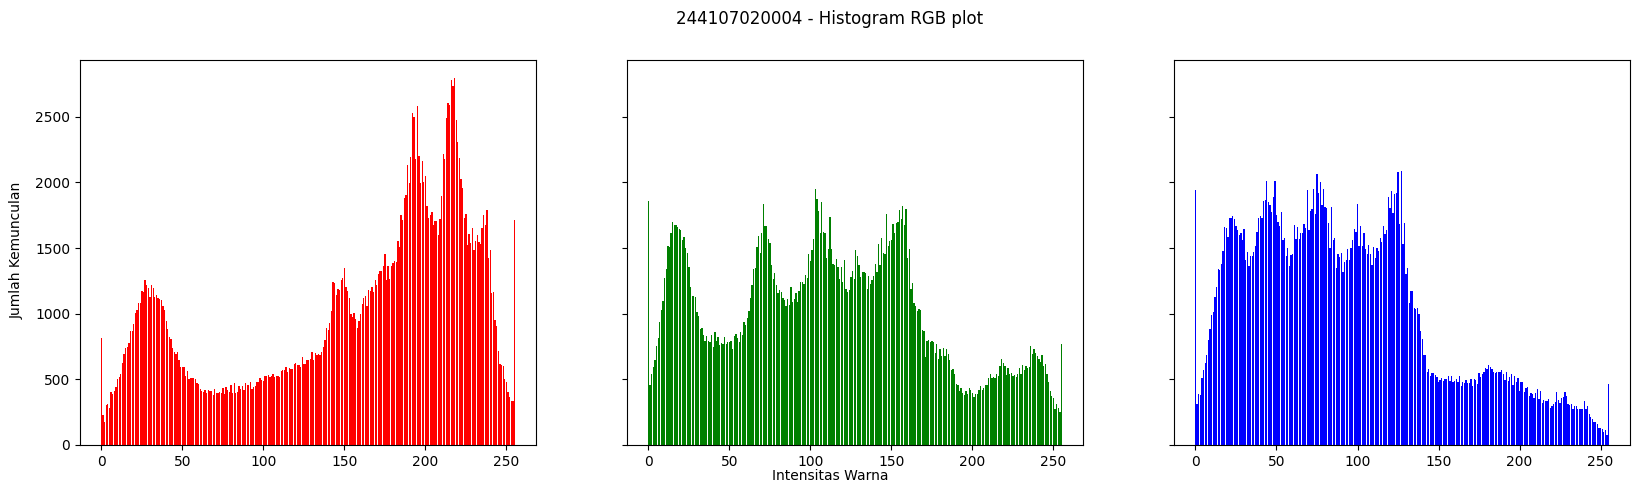

In [5]:
#membuat histogram image (manual)
img = cv.imread(CONTOH + '/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20,5), sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

**Membuat Histogram Dari KTM1b**

<BarContainer object of 256 artists>

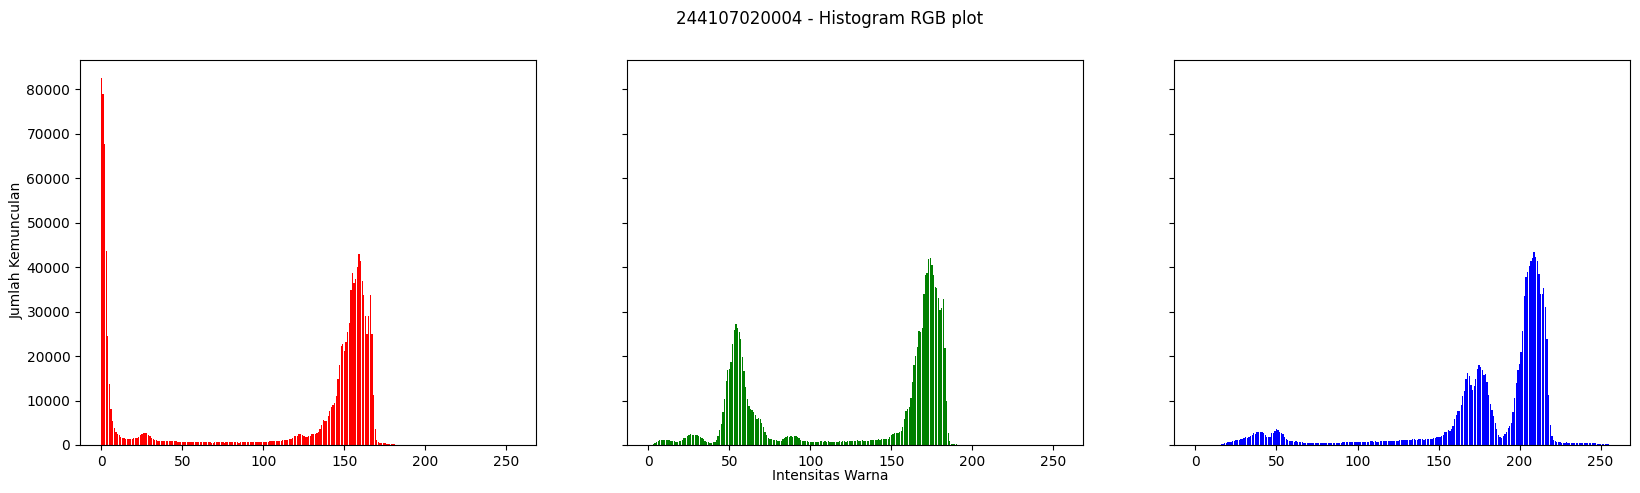

In [6]:
#membuat histogram image (manual)
ktm1b = cv.imread(BASE + '/KTM1b.jpg')
ktm1b = cv.cvtColor(ktm1b, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(ktm1b)
names = np.arange(256)

red_ktm1b = [0]*256
green_ktm1b = [0]*256
blue_ktm1b = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red_ktm1b[ktm1b[y][x][0]] += 1
        green_ktm1b[ktm1b[y][x][1]] += 1
        blue_ktm1b[ktm1b[y][x][2]] += 1

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20,5), sharex=True, sharey=True)

fig.suptitle(NIM + ' - Histogram RGB plot')

fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')

fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red_ktm1b, color='red')
axs[1].bar(names, green_ktm1b, color='green')
axs[2].bar(names, blue_ktm1b, color='blue')

**Pertanyaan Praktikum E1**

**Pertanyaan 1**

Lena

<BarContainer object of 256 artists>

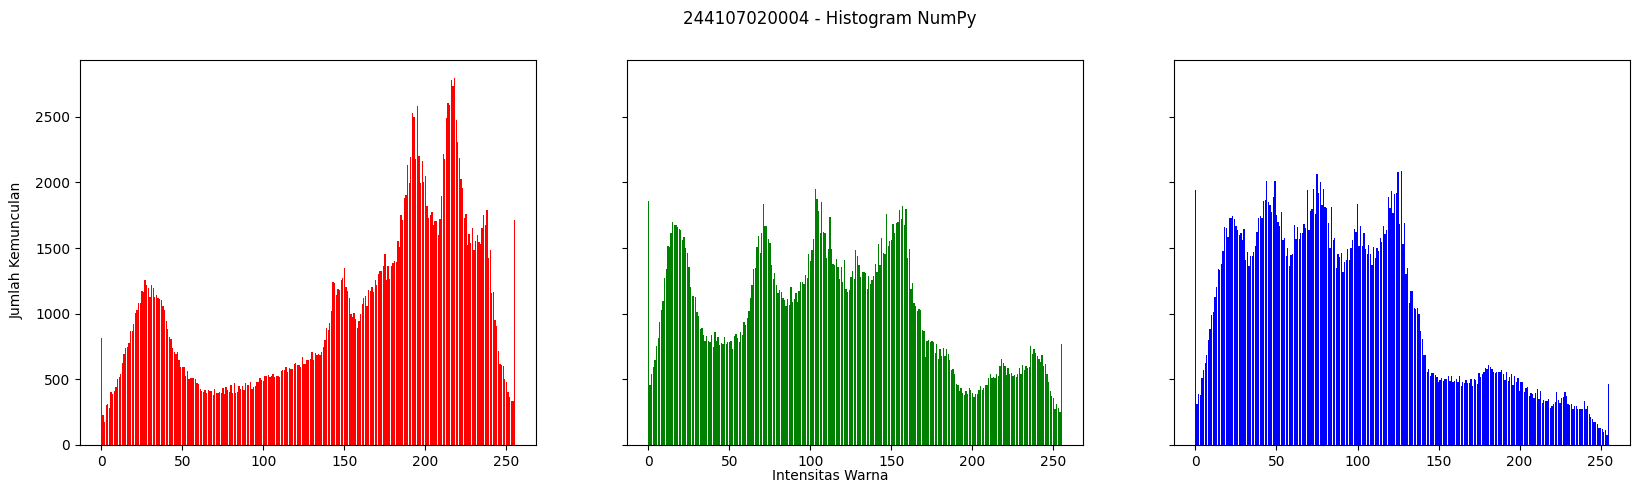

In [7]:
# Histogram Menggunakan Numpy
hist_numpy_red, _ = np.histogram(
    img[:,:,0],
    bins=256,
    range=(0,256)
)

hist_numpy_green, _ = np.histogram(
    img[:,:,1],
    bins=256,
    range=(0,256)
)

hist_numpy_blue, _ = np.histogram(
    img[:,:,2],
    bins=256,
    range=(0,256)
)

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

fig.suptitle(NIM + ' - Histogram NumPy')

fig.text(0.09, 0.5,'Jumlah Kemunculan',va='center',rotation='vertical')

fig.text(0.5, 0.04,'Intensitas Warna',ha='center')

axs[0].bar(names, hist_numpy_red, color='red')
axs[1].bar(names, hist_numpy_green, color='green')
axs[2].bar(names, hist_numpy_blue, color='blue')


<BarContainer object of 256 artists>

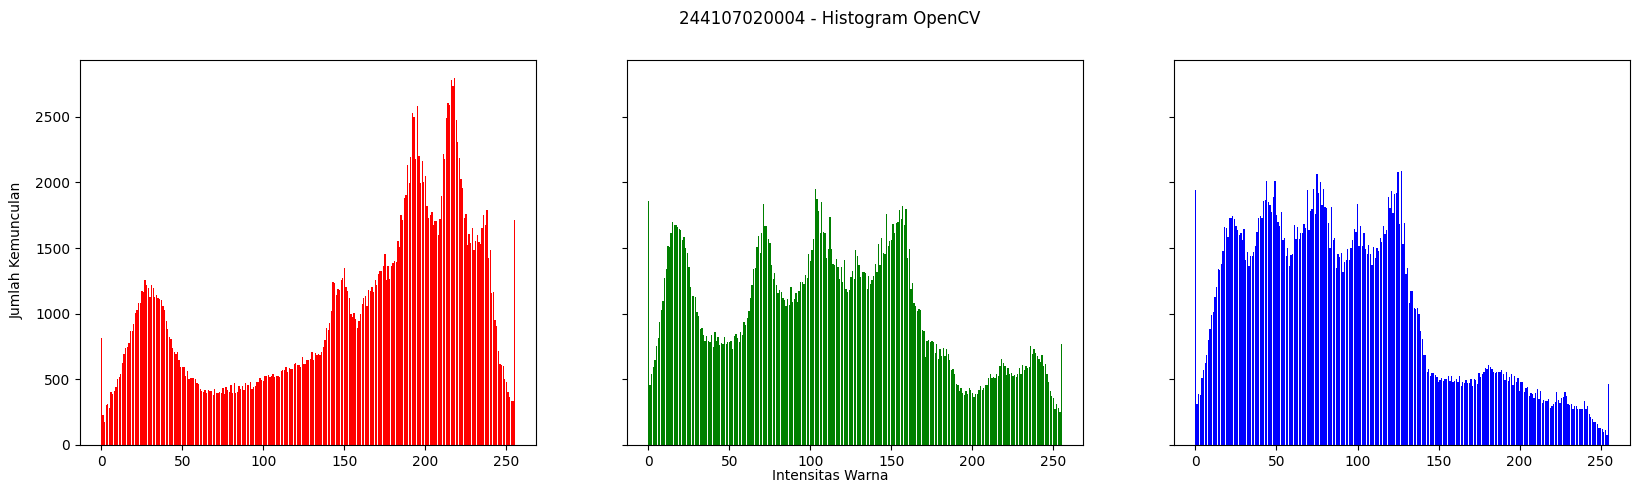

In [8]:
# Histogram Menggunakan OpenCV
hist_cv_red = cv.calcHist(
    [img], [0], None, [256], [0,256]
).flatten()

hist_cv_green = cv.calcHist(
    [img], [1], None, [256], [0,256]
).flatten()

hist_cv_blue = cv.calcHist(
    [img], [2], None, [256], [0,256]
).flatten()

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

fig.suptitle(NIM + ' - Histogram OpenCV')

fig.text(0.09, 0.5,'Jumlah Kemunculan',va='center',rotation='vertical')

fig.text(0.5, 0.04,'Intensitas Warna',ha='center')

axs[0].bar(names, hist_cv_red, color='red')
axs[1].bar(names, hist_cv_green, color='green')
axs[2].bar(names, hist_cv_blue, color='blue')

In [9]:
# Membandingkan hasil NumPy dan OpenCV

selisih_red = np.max(np.abs(hist_numpy_red - hist_cv_red))

selisih_green = np.max(np.abs(hist_numpy_green - hist_cv_green))

selisih_blue = np.max(np.abs(hist_numpy_blue - hist_cv_blue))

# Membandingkan hasil NumPy dan Manual
diff_red = np.max(np.abs(np.array(red) - hist_numpy_red))
diff_green = np.max(np.abs(np.array(green) - hist_numpy_green))
diff_blue = np.max(np.abs(np.array(blue) - hist_numpy_blue))


print('Selisih maksimum NumPy vs OpenCV')
print('Red   :', selisih_red)
print('Green :', selisih_green)
print('Blue  :', selisih_blue)
print('')
print('Selisih maksimum Manual vs NumPy')
print('Red   :', diff_red)
print('Green :', diff_green)
print('Blue  :', diff_blue)

Selisih maksimum NumPy vs OpenCV
Red   : 0.0
Green : 0.0
Blue  : 0.0

Selisih maksimum Manual vs NumPy
Red   : 0
Green : 0
Blue  : 0


KTM_1b

<BarContainer object of 256 artists>

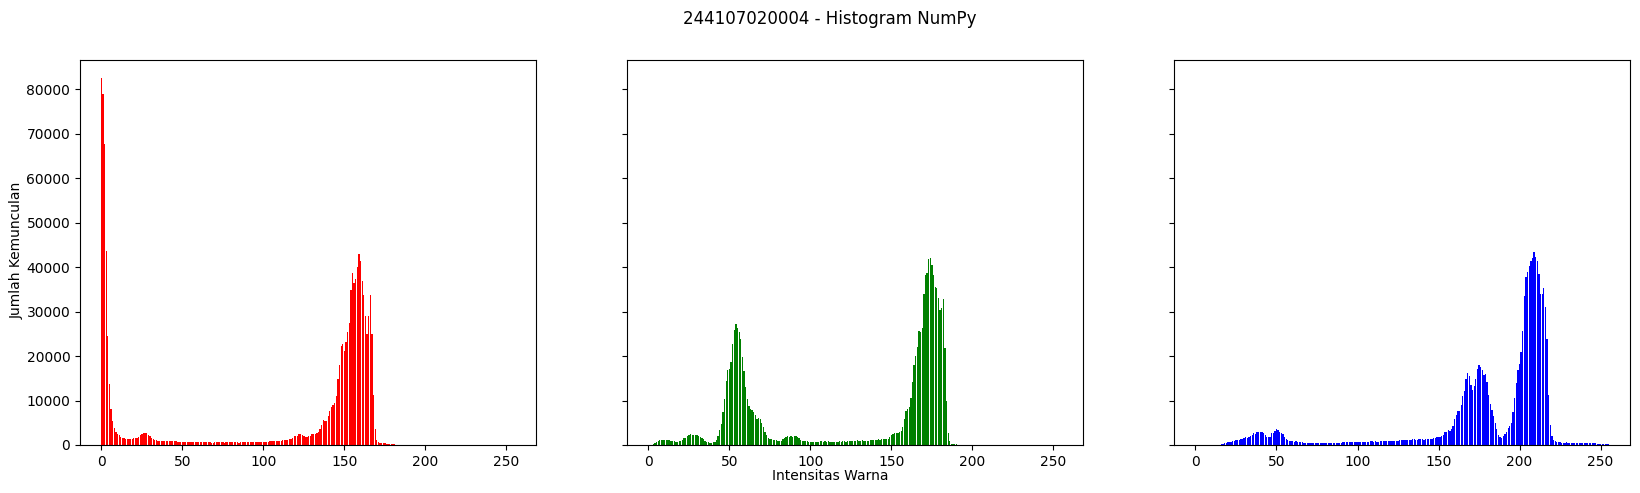

In [10]:
# Histogram Menggunakan Numpy
hist_numpy_red_ktm1b, _ = np.histogram(
    ktm1b[:,:,0],
    bins=256,
    range=(0,256)
)

hist_numpy_green_ktm1b, _ = np.histogram(
    ktm1b[:,:,1],
    bins=256,
    range=(0,256)
)

hist_numpy_blue_ktm1b, _ = np.histogram(
    ktm1b[:,:,2],
    bins=256,
    range=(0,256)
)

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

fig.suptitle(NIM + ' - Histogram NumPy')

fig.text(0.09, 0.5,'Jumlah Kemunculan',va='center',rotation='vertical')

fig.text(0.5, 0.04,'Intensitas Warna',ha='center')

axs[0].bar(names, hist_numpy_red_ktm1b, color='red')
axs[1].bar(names, hist_numpy_green_ktm1b, color='green')
axs[2].bar(names, hist_numpy_blue_ktm1b, color='blue')

<BarContainer object of 256 artists>

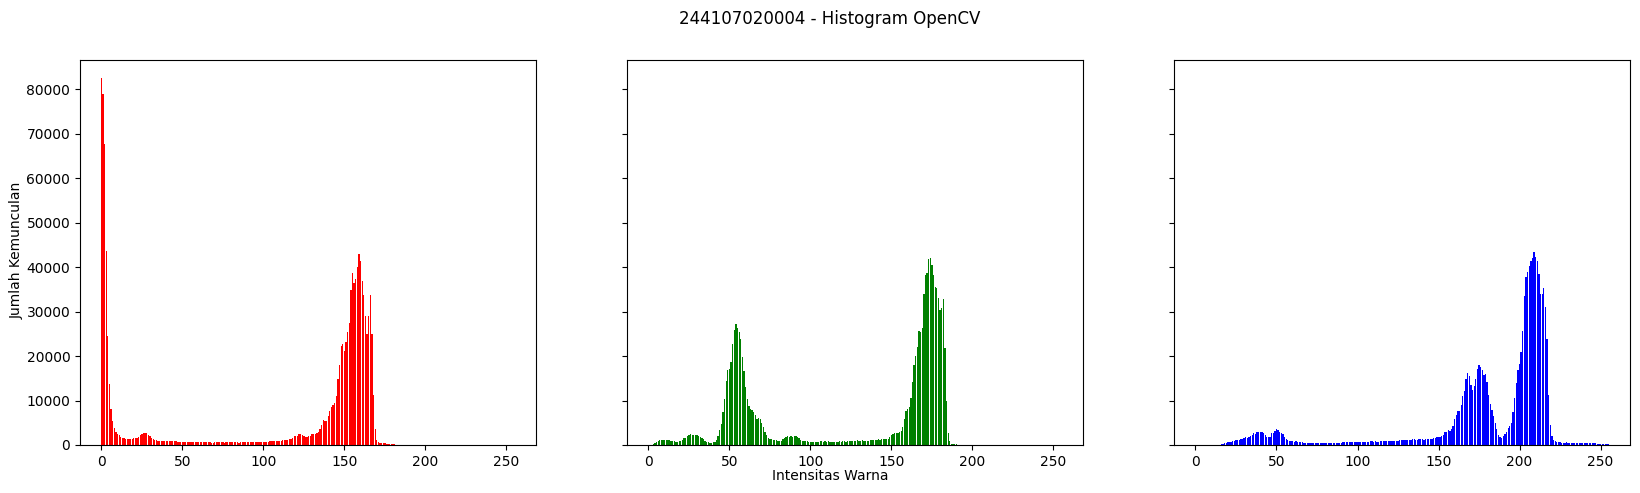

In [11]:
# Histogram Menggunakan OpenCV
hist_cv_red_ktm1b = cv.calcHist(
    [ktm1b], [0], None, [256], [0,256]
).flatten()

hist_cv_green_ktm1b = cv.calcHist(
    [ktm1b], [1], None, [256], [0,256]
).flatten()

hist_cv_blue_ktm1b = cv.calcHist(
    [ktm1b], [2], None, [256], [0,256]
).flatten()

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

fig.suptitle(NIM + ' - Histogram OpenCV')

fig.text(0.09, 0.5,'Jumlah Kemunculan',va='center',rotation='vertical')

fig.text(0.5, 0.04,'Intensitas Warna',ha='center')

axs[0].bar(names, hist_cv_red_ktm1b, color='red')
axs[1].bar(names, hist_cv_green_ktm1b, color='green')
axs[2].bar(names, hist_cv_blue_ktm1b, color='blue')

In [12]:
# Membandingkan hasil NumPy dan OpenCV

selisih_red_ktm1b = np.max(np.abs(hist_numpy_red_ktm1b - hist_cv_red_ktm1b))

selisih_green_ktm1b = np.max(np.abs(hist_numpy_green_ktm1b - hist_cv_green_ktm1b))

selisih_blue_ktm1b = np.max(np.abs(hist_numpy_blue_ktm1b - hist_cv_blue_ktm1b))

# Membandingkan hasil NumPy dan Manual
diff_red_ktm1b = np.max(np.abs(np.array(red_ktm1b) - hist_numpy_red_ktm1b))
diff_green_ktm1b = np.max(np.abs(np.array(green_ktm1b) - hist_numpy_green_ktm1b))
diff_blue_ktm1b = np.max(np.abs(np.array(blue_ktm1b) - hist_numpy_blue_ktm1b))


print('Selisih maksimum NumPy vs OpenCV')
print('Red   :', selisih_red_ktm1b)
print('Green :', selisih_green_ktm1b)
print('Blue  :', selisih_blue_ktm1b)
print('')
print('Selisih maksimum Manual vs NumPy')
print('Red   :', diff_red_ktm1b)
print('Green :', diff_green_ktm1b)
print('Blue  :', diff_blue_ktm1b)

Selisih maksimum NumPy vs OpenCV
Red   : 0.0
Green : 0.0
Blue  : 0.0

Selisih maksimum Manual vs NumPy
Red   : 0
Green : 0
Blue  : 0


**Pertanyaan 2**

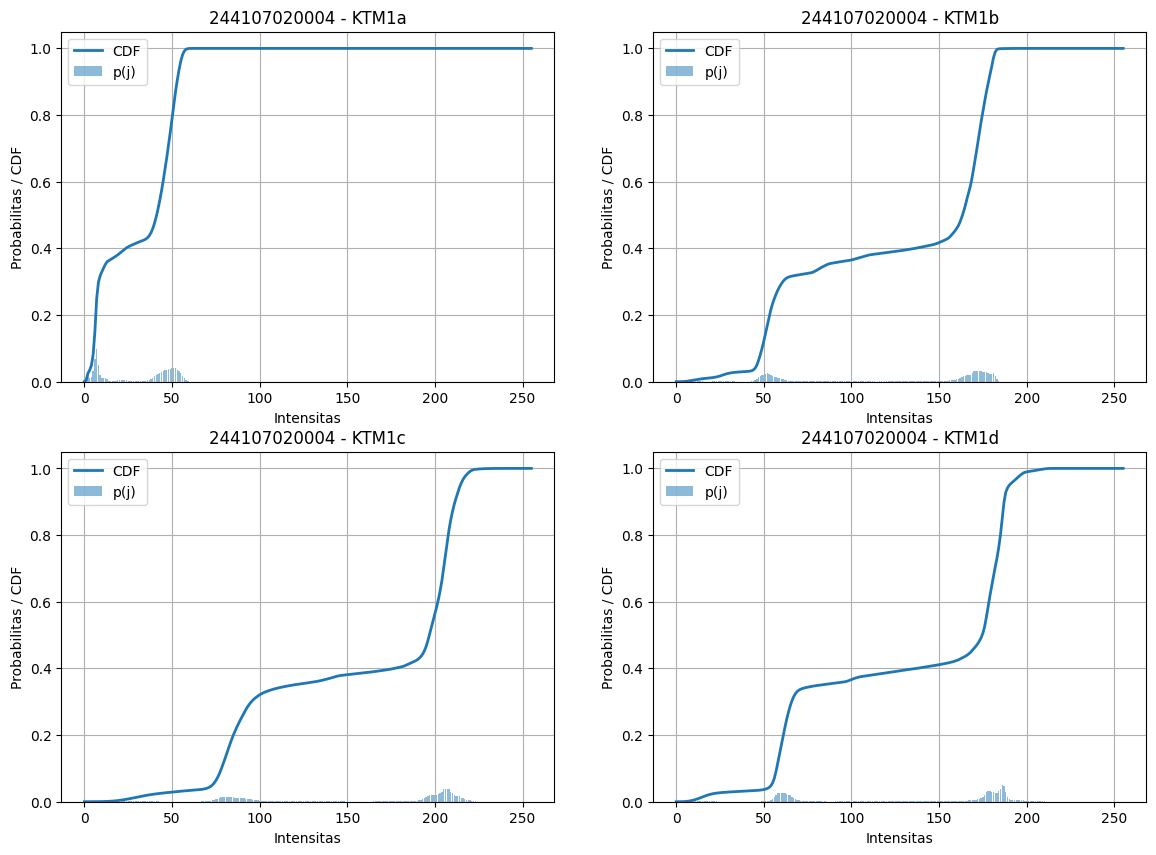

In [13]:
ktm1a = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
ktm1b = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
ktm1c = cv.imread(BASE + '/KTM1c.jpg', cv.IMREAD_GRAYSCALE)
ktm1d = cv.imread(BASE + '/KTM1d.jpg', cv.IMREAD_GRAYSCALE)

# Menyimpan citra dalam list
ktm = [ktm1a, ktm1b, ktm1c, ktm1d]
nama = ['KTM1a', 'KTM1b', 'KTM1c', 'KTM1d']

# Membuat figure 2 x 2
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for ax, img, nama_img in zip(axs.ravel(), ktm, nama):

    # Histogram
    h, _ = np.histogram(img, bins=256, range=(0, 256))

    # Histogram ternormalisasi p(j)
    p = h / img.size

    # CDF
    cdf = np.cumsum(p)

    # Plot histogram ternormalisasi
    ax.bar(np.arange(256), p, alpha=0.5, label='p(j)')

    # Plot CDF
    ax.plot(np.arange(256), cdf, linewidth=2, label='CDF')

    ax.set_title(NIM + ' - ' + nama_img)
    ax.set_xlabel('Intensitas')
    ax.set_ylabel('Probabilitas / CDF')
    ax.legend()
    ax.grid()



Berdasarkan histogram ternormalisasi dan kurva CDF pada KTM1a sampai KTM1d, terlihat adanya perbedaan distribusi intensitas pada setiap citra. Pada KTM1a, kurva CDF mengalami kenaikan yang cukup besar pada intensitas rendah, terutama sekitar 0–60, yang menunjukkan bahwa banyak piksel memiliki nilai intensitas rendah sehingga citra terlihat lebih gelap. Sementara itu, pada KTM1c dan KTM1d, kenaikan CDF utama berada pada intensitas yang lebih tinggi, sehingga menunjukkan bahwa citra memiliki lebih banyak piksel dengan intensitas yang lebih terang.

Perbedaan tersebut berkaitan dengan kondisi pencahayaan saat proses akuisisi citra pada Pertemuan 2. KTM1a diambil dalam kondisi ruangan yang lebih gelap sehingga cahaya yang diterima kamera lebih sedikit dan distribusi piksel cenderung berada pada intensitas rendah. Pada kondisi pencahayaan yang lebih kuat, seperti penggunaan flash atau pengambilan gambar di luar ruangan, distribusi intensitas bergeser ke nilai yang lebih tinggi. Hal ini menyebabkan bentuk histogram dan kurva CDF setiap citra berbeda.

**Pertanyaan 3**

<BarContainer object of 256 artists>

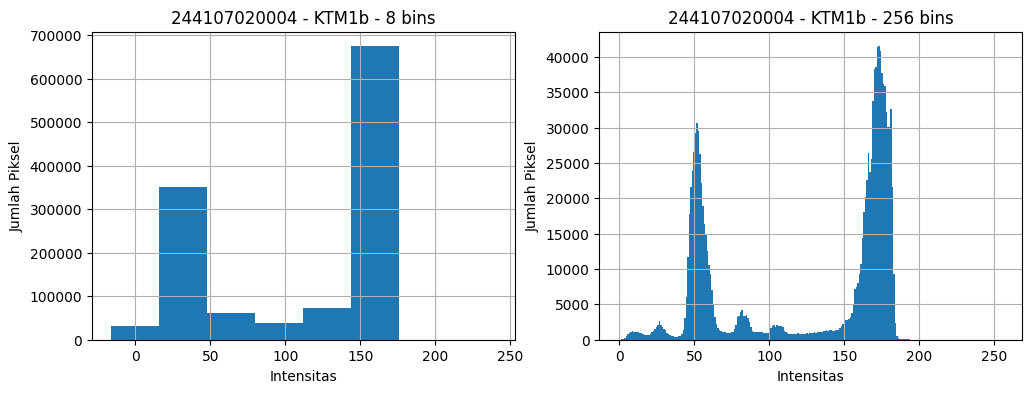

In [14]:
ktm1b = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

# Histogram dengan jumlah bin sesuai PARAM
hist_param, batas_param = np.histogram(
    ktm1b,
    bins=PARAM['bins'],
    range=(0, 256)
)

# Histogram dengan 256 bin
hist_256, batas_256 = np.histogram(
    ktm1b,
    bins=256,
    range=(0, 256)
)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Histogram PARAM['bins']
axs[0].set_title(NIM + ' - KTM1b - ' + str(PARAM['bins']) + ' bins')
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Jumlah Piksel')
axs[0].grid()
axs[0].bar(batas_param[:-1],hist_param,width=256 / PARAM['bins'])

# Histogram 256 bins
axs[1].set_title(NIM + ' - KTM1b - 256 bins')
axs[1].set_xlabel('Intensitas')
axs[1].set_ylabel('Jumlah Piksel')
axs[1].grid()
axs[1].bar(batas_256[:-1],hist_256,width=1)



Berdasarkan hasil perbandingan histogram KTM1b, penggunaan 256 bin memberikan informasi distribusi intensitas yang lebih detail. Setiap tingkat intensitas dari 0 sampai 255 dapat diamati dengan lebih jelas, sehingga puncak dan perubahan kecil pada distribusi piksel masih terlihat. Pada histogram dengan 8 bin, rentang intensitas yang berdekatan digabungkan menjadi satu kelompok sehingga bentuk histogram menjadi lebih sederhana.

Informasi yang hilang ketika jumlah bin dikurangi adalah detail persebaran piksel pada setiap tingkat intensitas. Sebagai contoh, pada histogram 256 bin terlihat adanya beberapa puncak dan perubahan distribusi di sekitar intensitas 50 serta 170–180. Pada histogram 8 bin, detail tersebut digabungkan ke dalam rentang yang lebih besar sehingga perubahan kecil tersebut tidak dapat diamati secara jelas.

# **E-2 PERCOBAAN HISTOGRAM EQUALIZATION**

**Tahap 1**

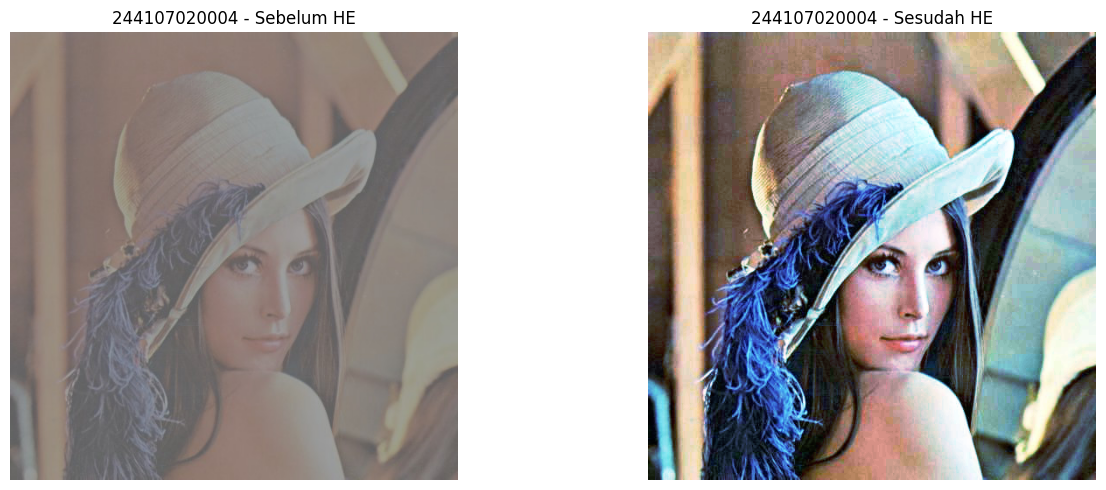

<BarContainer object of 256 artists>

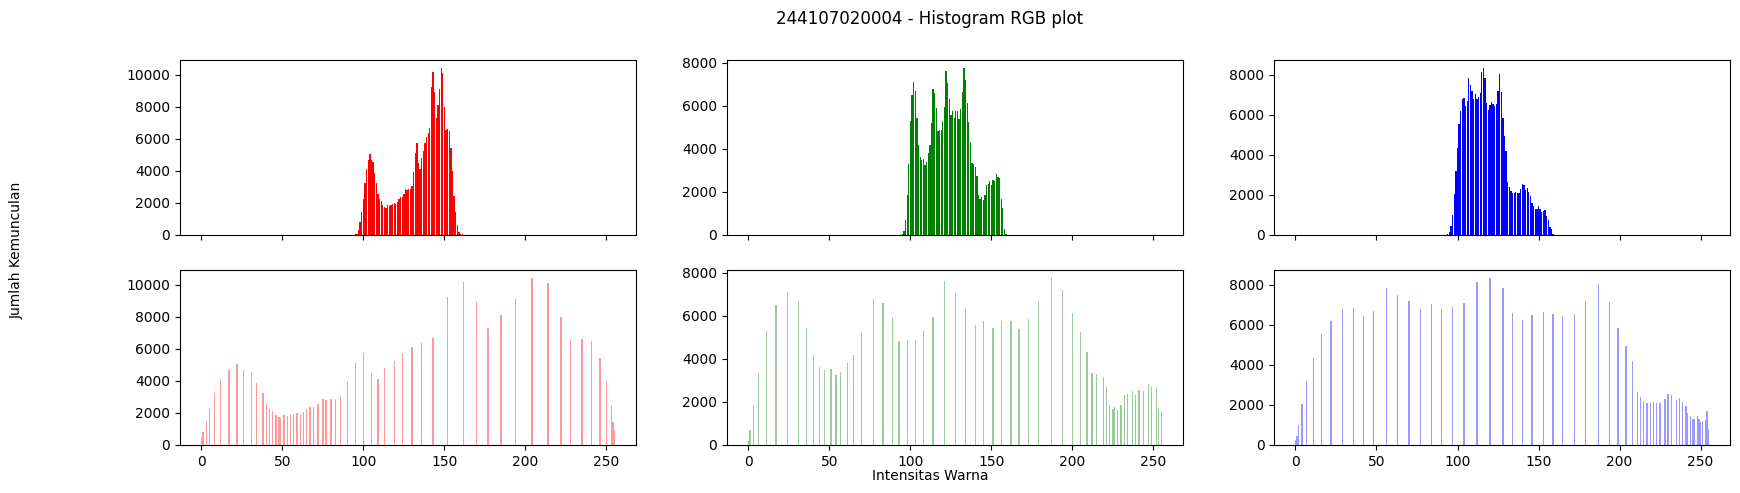

In [15]:
def he_manual(channel):

    h = np.bincount(channel.ravel(),minlength=256)

    p = h / channel.size

    cdf = np.cumsum(p)

    s = np.round(255 * cdf).astype(np.uint8)

    hasil = s[channel]

    return hasil

lena_lc = cv.imread(CONTOH + '/lena_lc.jpg')

lena_lc = cv.cvtColor(lena_lc,cv.COLOR_BGR2RGB)


red_eq = he_manual(lena_lc[:, :, 0])

green_eq = he_manual(lena_lc[:, :, 1])

blue_eq = he_manual(lena_lc[:, :, 2])

lena_he = cv.merge([red_eq,green_eq,blue_eq])


plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.imshow(lena_lc)
plt.title(NIM + ' - Sebelum HE')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(lena_he)
plt.title(NIM + ' - Sesudah HE')
plt.axis('off')

plt.tight_layout()
plt.show()


height, width, depth = np.shape(lena_lc)

red_before = [0] * 256
green_before = [0] * 256
blue_before = [0] * 256

for y in range(height):
    for x in range(width):

        red_before[lena_lc[y][x][0]] += 1
        green_before[lena_lc[y][x][1]] += 1
        blue_before[lena_lc[y][x][2]] += 1

red_after = [0] * 256
green_after = [0] * 256
blue_after = [0] * 256

for y in range(height):
    for x in range(width):

        red_after[lena_he[y][x][0]] += 1
        green_after[lena_he[y][x][1]] += 1
        blue_after[lena_he[y][x][2]] += 1


names = np.arange(256)

fig, axs = plt.subplots(2,3,figsize=(20,5),sharex=True,sharey=False
)
fig.suptitle(NIM + ' - Histogram RGB plot')
fig.text(0.04,0.5,'Jumlah Kemunculan',va='center',rotation='vertical')
fig.text(0.5,0.04,'Intensitas Warna',ha='center')

axs[0,0].bar(names,red_before,color='red')
axs[0,1].bar(names,green_before,color='green')
axs[0,2].bar(names,blue_before,color='blue')

axs[1,0].bar(names,red_after,color='red',alpha=0.4)
axs[1,1].bar(names,green_after,color='green',alpha=0.4)
axs[1,2].bar(names,blue_after,color='blue',alpha=0.4)




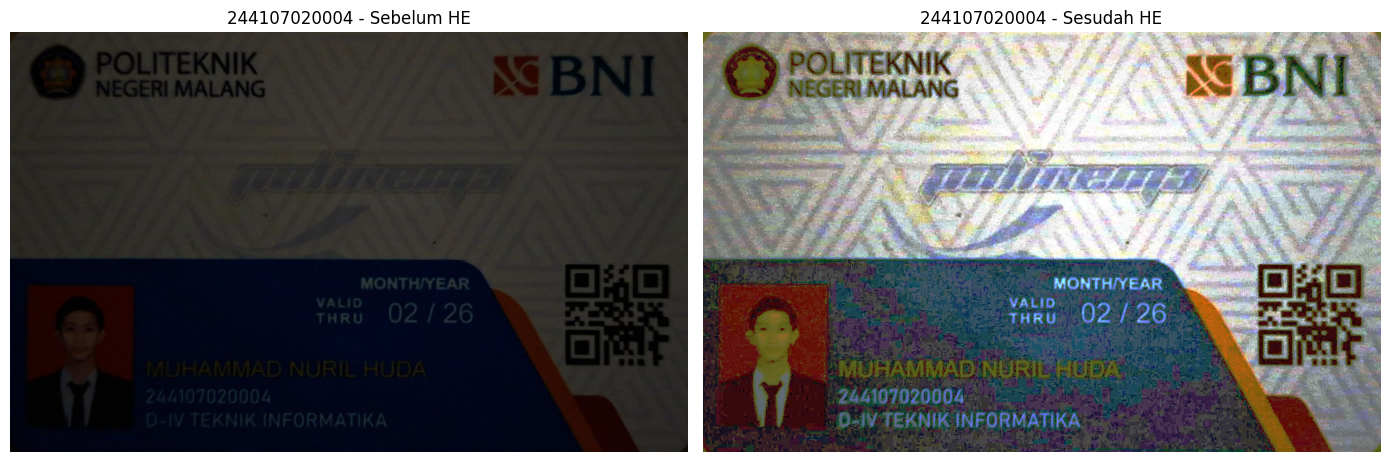

<BarContainer object of 256 artists>

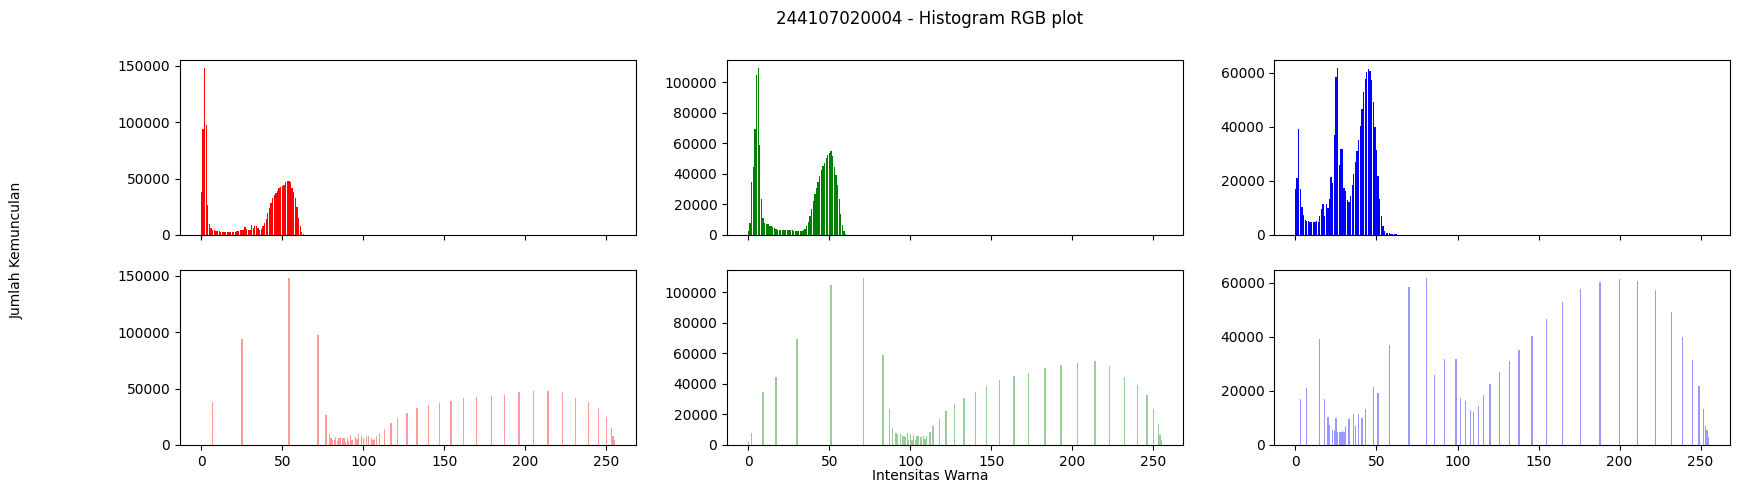

In [16]:
def he_manual(channel):

    h = np.bincount(channel.ravel(),minlength=256)

    p = h / channel.size

    cdf = np.cumsum(p)

    s = np.round(255 * cdf).astype(np.uint8)

    hasil = s[channel]

    return hasil

ktm1a = cv.imread(BASE + '/KTM1a.jpg')
ktm1a = cv.cvtColor(ktm1a,cv.COLOR_BGR2RGB)


red_eq = he_manual(ktm1a[:, :, 0])

green_eq = he_manual(ktm1a[:, :, 1])

blue_eq = he_manual(ktm1a[:, :, 2])

ktm1a_he = cv.merge([red_eq,green_eq,blue_eq])


plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.imshow(ktm1a)
plt.title(NIM + ' - Sebelum HE')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(ktm1a_he)
plt.title(NIM + ' - Sesudah HE')
plt.axis('off')

plt.tight_layout()
plt.show()


height, width, depth = np.shape(ktm1a)

red_before = [0] * 256
green_before = [0] * 256
blue_before = [0] * 256

for y in range(height):
    for x in range(width):

        red_before[ktm1a[y][x][0]] += 1
        green_before[ktm1a[y][x][1]] += 1
        blue_before[ktm1a[y][x][2]] += 1

red_after = [0] * 256
green_after = [0] * 256
blue_after = [0] * 256

for y in range(height):
    for x in range(width):

        red_after[ktm1a_he[y][x][0]] += 1
        green_after[ktm1a_he[y][x][1]] += 1
        blue_after[ktm1a_he[y][x][2]] += 1


names = np.arange(256)

fig, axs = plt.subplots(2,3,figsize=(20,5),sharex=True,sharey=False)
fig.suptitle(NIM + ' - Histogram RGB plot')
fig.text(0.04,0.5,'Jumlah Kemunculan',va='center',rotation='vertical')
fig.text(0.5,0.04,'Intensitas Warna',ha='center')

axs[0,0].bar(names,red_before,color='red')
axs[0,1].bar(names,green_before,color='green')
axs[0,2].bar(names,blue_before,color='blue')

axs[1,0].bar(names,red_after,color='red',alpha=0.4)
axs[1,1].bar(names,green_after,color='green',alpha=0.4)
axs[1,2].bar(names,blue_after,color='blue',alpha=0.4)





**Tahap 2**

Selisih maksimum Lena = 0


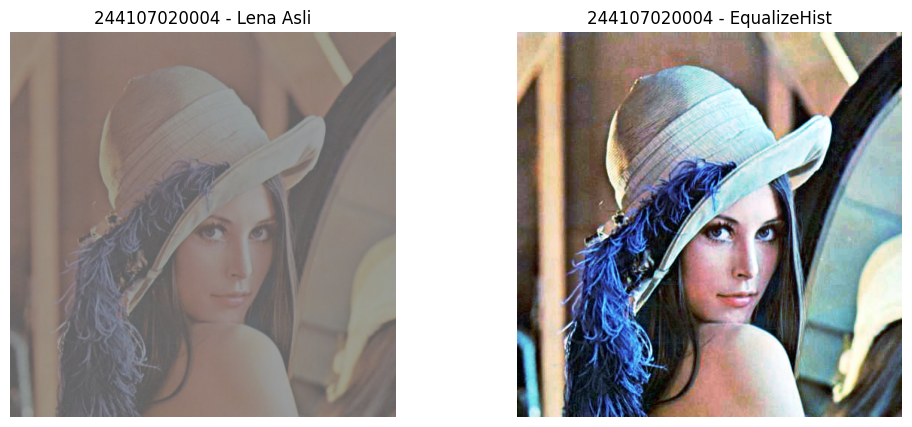

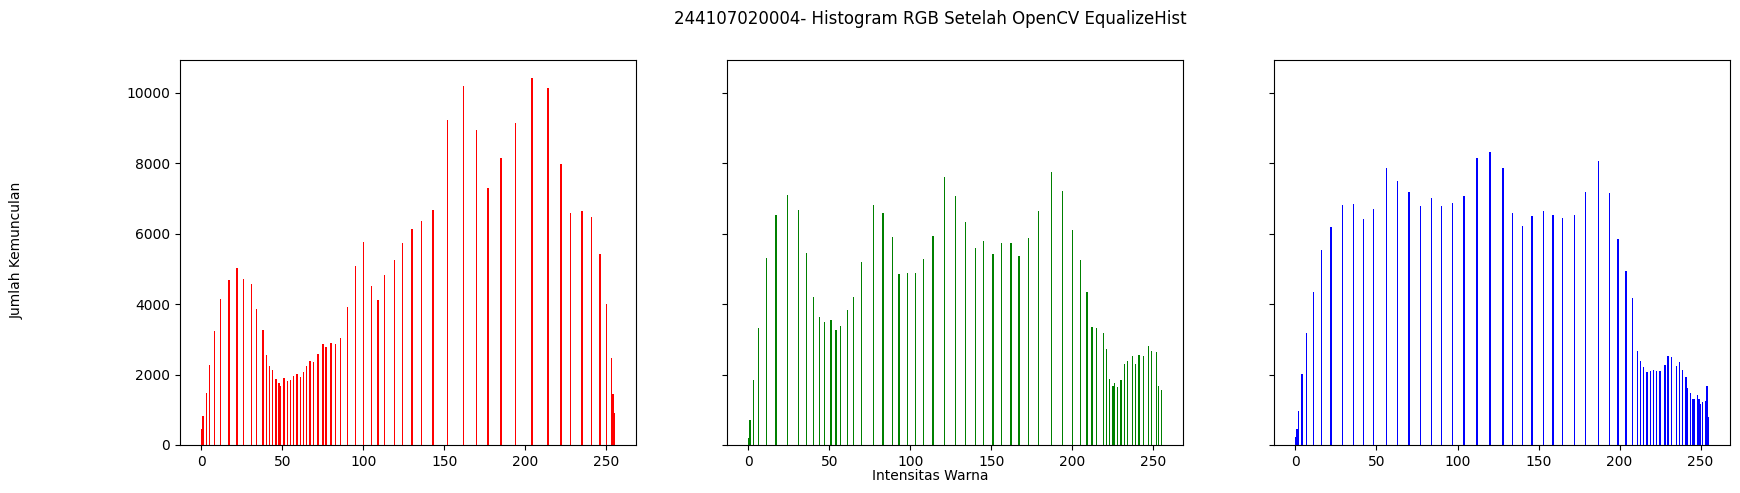

In [17]:
lena_lc = cv.imread(CONTOH + '/lena_lc.jpg')
lena_rgb = cv.cvtColor(lena_lc,cv.COLOR_BGR2RGB)

b, g, r = cv.split(lena_lc)

b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

lena_cv = cv.merge([
    b_equalized,
    g_equalized,
    r_equalized
])

lena_cv = cv.cvtColor(lena_cv,cv.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(lena_rgb)
plt.title(NIM + ' - Lena Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(lena_cv)
plt.title(NIM + ' - EqualizeHist')
plt.axis('off')

hist_r, _ = np.histogram(lena_cv[:, :, 0],bins=256,range=(0, 256))

hist_g, _ = np.histogram(lena_cv[:, :, 1],bins=256,range=(0, 256))

hist_b, _ = np.histogram(lena_cv[:, :, 2],bins=256,range=(0, 256))

names = np.arange(256)

fig, axs = plt.subplots(1,3,figsize=(20,5),sharex=True,sharey=True)

fig.suptitle(NIM + '- Histogram RGB Setelah OpenCV EqualizeHist')

axs[0].bar(names,hist_r,color='red')
axs[1].bar(names,hist_g,color='green')
axs[2].bar(names,hist_b,color='blue')

fig.text(0.04,0.5,'Jumlah Kemunculan',va='center',rotation='vertical')
fig.text(0.5,0.04,'Intensitas Warna',ha='center')

selisih = np.max(np.abs(lena_he-lena_cv))

print('Selisih maksimum Lena =', (selisih))

Selisih maksimum KTM1A = 7


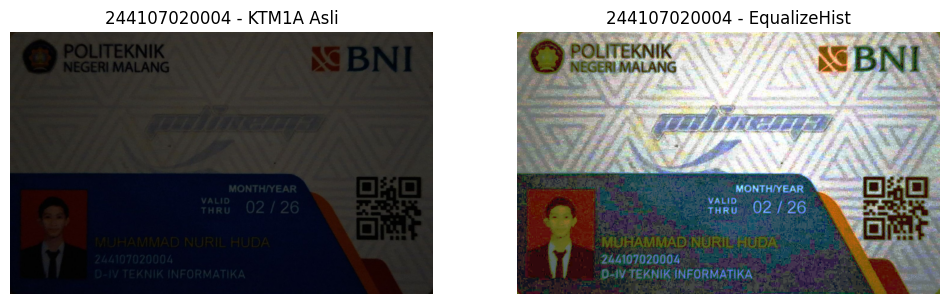

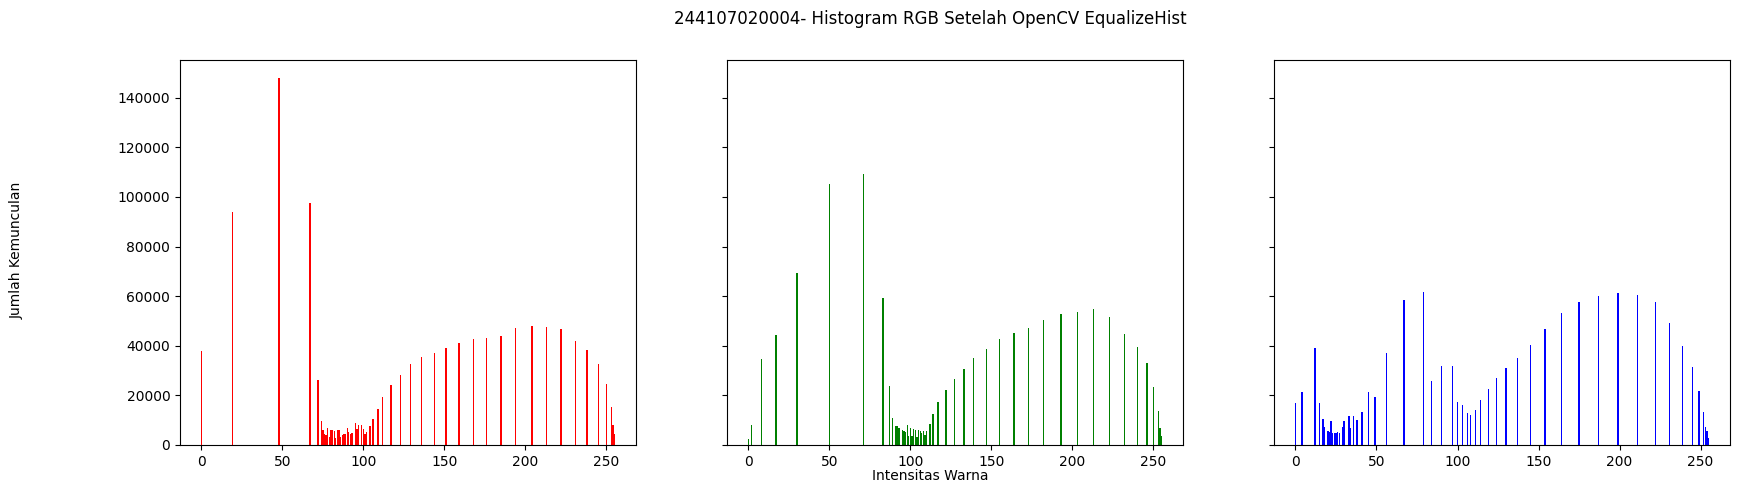

In [18]:
ktm1a = cv.imread(BASE + '/KTM1a.jpg')
ktm1a_rgb = cv.cvtColor(ktm1a,cv.COLOR_BGR2RGB)

b, g, r = cv.split(ktm1a)

b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

ktm1a_cv = cv.merge([
    b_equalized,
    g_equalized,
    r_equalized
])

ktm1a_cv = cv.cvtColor(ktm1a_cv,cv.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(ktm1a_rgb)
plt.title(NIM + ' - KTM1A Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(ktm1a_cv)
plt.title(NIM + ' - EqualizeHist')
plt.axis('off')

hist_r_ktm1a, _ = np.histogram(ktm1a_cv[:, :, 0],bins=256,range=(0, 256))

hist_g_ktm1a, _ = np.histogram(ktm1a_cv[:, :, 1],bins=256,range=(0, 256))

hist_b_ktm1a, _ = np.histogram(ktm1a_cv[:, :, 2],bins=256,range=(0, 256))

names = np.arange(256)

fig, axs = plt.subplots(1,3,figsize=(20,5),sharex=True,sharey=True)

fig.suptitle(NIM + '- Histogram RGB Setelah OpenCV EqualizeHist')

axs[0].bar(names,hist_r_ktm1a,color='red')
axs[1].bar(names,hist_g_ktm1a,color='green')
axs[2].bar(names,hist_b_ktm1a,color='blue')

fig.text(0.04,0.5,'Jumlah Kemunculan',va='center',rotation='vertical')
fig.text(0.5,0.04,'Intensitas Warna',ha='center')

selisih = np.max(np.abs(ktm1a_he-ktm1a_cv))

print('Selisih maksimum KTM1A =', (selisih))

Selisih maksimum sebesar 7 terjadi karena implementasi manual dan fungsi cv.equalizeHist() menggunakan proses normalisasi CDF serta pembulatan nilai yang sedikit berbeda. Perbedaan ini menyebabkan beberapa piksel memiliki nilai intensitas yang tidak sama persis, meskipun hasil citra yang dihasilkan secara visual tetap hampir identik.

**Tahap 3**

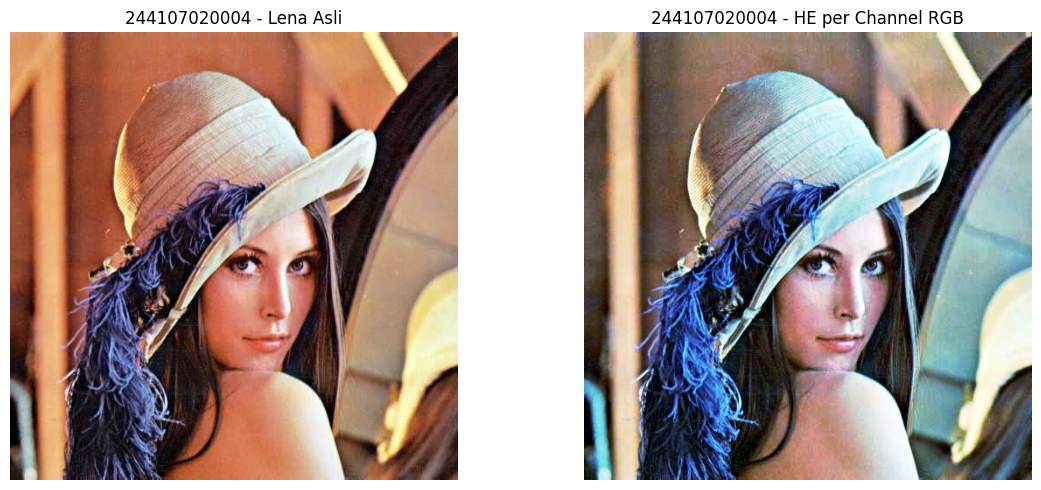

In [19]:
berkas = CONTOH + '/lena.jpg'
bgr = cv.imread(berkas)

# Cara 1: setiap channel diekualisasi sendiri
kanal = list(cv.split(bgr))

for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

he_rgb = cv.merge(kanal)

rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
he_rgb_show = cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title(NIM + ' - Lena Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(he_rgb_show)
plt.title(NIM + ' - HE per Channel RGB')
plt.axis('off')

plt.tight_layout()
plt.show()

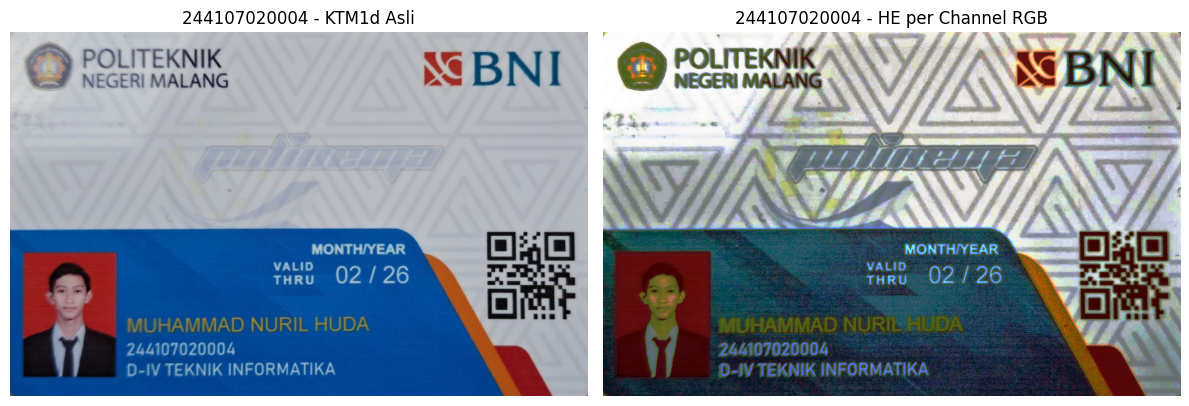

In [20]:
berkas = BASE + '/KTM1d.jpg'
bgr = cv.imread(berkas)

# Cara 1: setiap channel diekualisasi sendiri
kanal = list(cv.split(bgr))

for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

he_rgb = cv.merge(kanal)

rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
he_rgb_show = cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title(NIM + ' - KTM1d Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(he_rgb_show)
plt.title(NIM + ' - HE per Channel RGB')
plt.axis('off')

plt.tight_layout()
plt.show()

**Tahap 4**

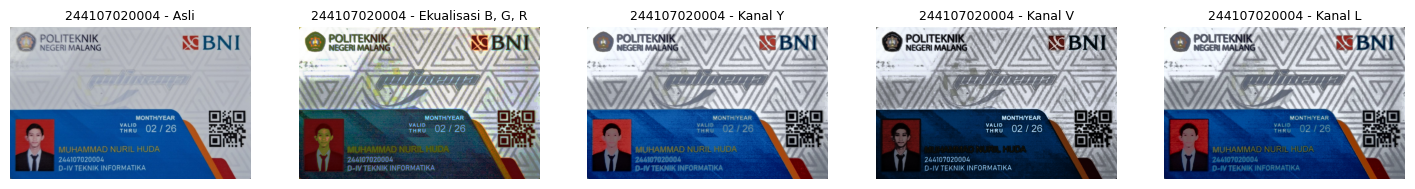

In [21]:
berkas = BASE + '/KTM1d.jpg'
bgr = cv.imread(berkas)

# Ekualisasi per kanal RGB
kanal = list(cv.split(bgr))

for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

he_rgb = cv.merge(kanal)

# Ekualisasi Kanal Y (YCrCb)
ycrcb = cv.cvtColor(bgr,cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y),cr,cb]),cv.COLOR_YCrCb2BGR)

# Ekualisasi Kanal V (HSV)
hsv = cv.cvtColor(bgr,cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h,sat,cv.equalizeHist(v)]),cv.COLOR_HSV2BGR)

# Ekualisasi Kanal L (LAB)
lab = cv.cvtColor(bgr,cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l),a,b]),cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']

citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))

for i, (c, t) in enumerate(zip(citra, judul), 1):
 plt.subplot(1, 5, i)
 plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
 plt.title(NIM + ' - ' + t, fontsize=9)
 plt.axis('off')

plt.show()

In [22]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)

    h2 = cv.cvtColor(hasil,cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)

    d = np.abs(h1 - h2)

    d = np.minimum(d,180 - d)

    return d.mean()

print('%-22s %16s %16s'%('Cara','geser Hue (der)','rerata terang'))

for t, c in zip(judul, citra):
    print(
        '%-22s %16.2f %16.1f'
        %
        (
            t,
            geser_hue(bgr, c) * 2,
            cv.cvtColor(
                c,
                cv.COLOR_BGR2GRAY
            ).mean()
        )
    )

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            134.3
Ekualisasi B, G, R                65.48            128.6
Kanal Y                            1.42            131.5
Kanal V                            2.11            113.2
Kanal L                            4.48            123.2


 **1. Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada
citra Anda?**

Metode ekualisasi kanal B, G, dan R secara terpisah menghasilkan pergeseran Hue paling besar, yaitu 65,48 derajat. Nilai ini jauh lebih besar dibandingkan metode Y, V, maupun L, sehingga menunjukkan bahwa warna citra mengalami perubahan yang signifikan.

**2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis
nol? Kaitkan jawaban Anda dengan pembulatan dan pemotongan nilai ketika citra
dikembalikan ke ruang warna BGR.**

Meskipun yang diekualisasi hanya kanal terang (Y, V, atau L), citra tetap harus dikonversi kembali ke ruang warna BGR untuk ditampilkan. Pada proses konversi tersebut terjadi pembulatan (rounding) dan pemotongan nilai (clipping) piksel. Akibatnya nilai warna yang dihasilkan tidak selalu sama persis dengan citra asli sehingga masih muncul pergeseran Hue yang kecil meskipun informasi warna utama tidak diubah secara langsung.

**3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkan
alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian.**

Kanal Y (YCrCb) paling sesuai untuk foto KTM saya karena memiliki pergeseran Hue paling kecil, yaitu 1,42 derajat. Hal ini menunjukkan bahwa warna asli citra paling terjaga dibandingkan metode lainnya. Pada bagian foto KTM seperti warna kulit wajah, warna pakaian, dan latar belakang, hasil kanal Y terlihat paling mendekati citra asli namun dengan kontras yang lebih baik.



**4. Ulangi salah satu cara pada kanal terang dengan mengganti cv.equalizeHist menjadi
CLAHE yang memakai clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'],
PARAM['tile']). Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil
ekualisasi biasa.**

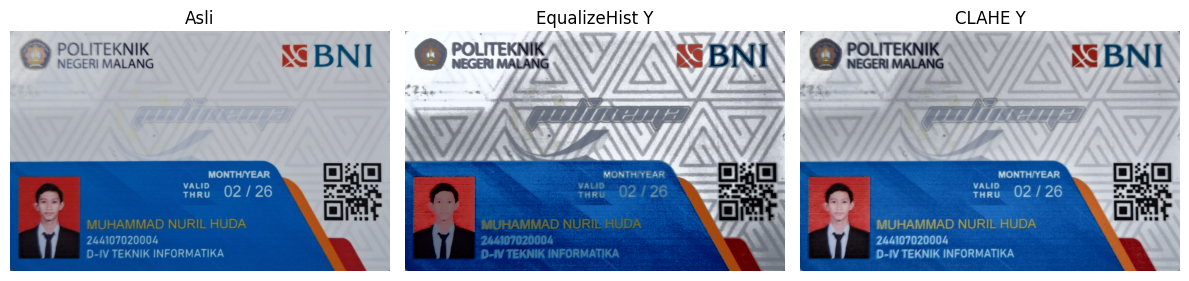


Metode                      geser Hue    rerata terang
EqualizeHist Y                   1.42            131.5
CLAHE Y                          0.07            135.5


In [23]:
# CLAHE pada Kanal Y
clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(
        PARAM['tile'],
        PARAM['tile']
    )
)

ycrcb = cv.cvtColor(bgr,cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
y_clahe = clahe.apply(y)

clahe_y = cv.cvtColor(
    cv.merge([
        y_clahe,
        cr,
        cb
    ]),
    cv.COLOR_YCrCb2BGR
)

# Menampilkan Perbedaan
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title('Asli')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv.cvtColor(he_y, cv.COLOR_BGR2RGB))
plt.title('EqualizeHist Y')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv.cvtColor(clahe_y, cv.COLOR_BGR2RGB))
plt.title('CLAHE Y')
plt.axis('off')

plt.tight_layout()
plt.show()

print('')
print('%-20s %16s %16s'%('Metode','geser Hue','rerata terang'))

print(
    '%-20s %16.2f %16.1f'
    %
    (
        'EqualizeHist Y',
        geser_hue(bgr, he_y) * 2,
        cv.cvtColor(
            he_y,
            cv.COLOR_BGR2GRAY
        ).mean()
    )
)

print(
    '%-20s %16.2f %16.1f'
    %
    (
        'CLAHE Y',
        geser_hue(bgr, clahe_y) * 2,
        cv.cvtColor(
            clahe_y,
            cv.COLOR_BGR2GRAY
        ).mean()
    )
)

CLAHE pada kanal Y menghasilkan pergeseran Hue sebesar 0,07°, lebih kecil dibandingkan EqualizeHist Y sebesar 1,42°. Rerata kecerahan CLAHE juga lebih tinggi (135,5) dibandingkan EqualizeHist (131,5). Hal ini menunjukkan bahwa CLAHE lebih mampu meningkatkan kontras dan kecerahan citra tanpa mengubah warna asli secara signifikan.


**Pertanyaan Praktikum E2**

**Pertanyan 1**

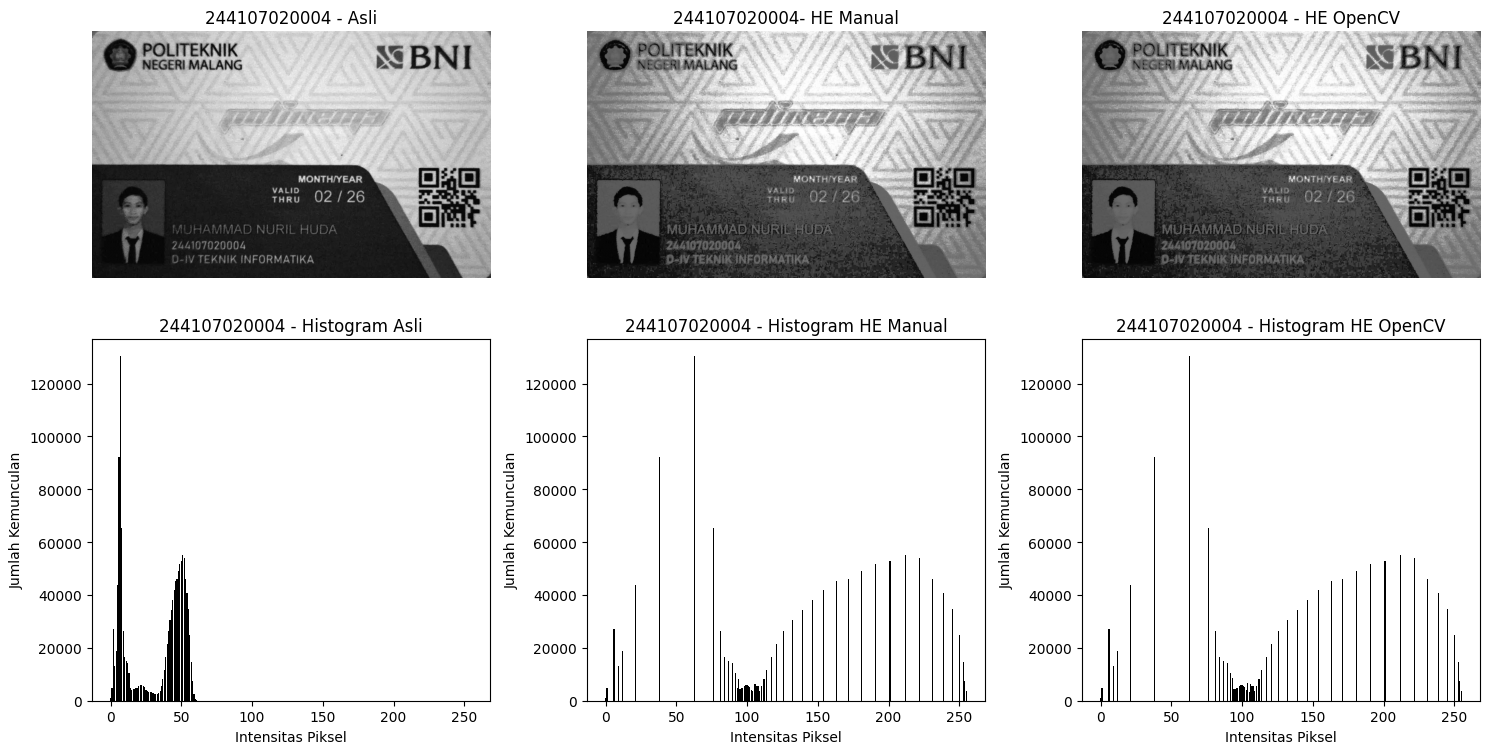


PSNR Asli vs HE Manual = 6.98
PSNR Asli vs HE OpenCV = 6.98 dB


In [28]:
ktm1a = cv.imread(BASE + '/KTM1a.jpg')
ktm1a_gray = cv.cvtColor(ktm1a,cv.COLOR_BGR2GRAY)

# Equalization Manual
def he_manual(ktm1a_gray):

    h = np.bincount(
        ktm1a_gray.ravel(),
        minlength=256
    )

    p = h / ktm1a_gray.size

    cdf = np.cumsum(p)

    s = np.round(
        255 * cdf
    ).astype(np.uint8)

    return s[ktm1a_gray]

ktm1a_gray_he_manual = he_manual(ktm1a_gray)

# Ekualisasi OpenCV
ktm1a_gray_he_cv = cv.equalizeHist(ktm1a_gray)

# Menampilkan
plt.figure(figsize=(15,8))

plt.subplot(2,3,1)
plt.imshow(ktm1a_gray, cmap='gray')
plt.title(NIM + ' - Asli')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(ktm1a_gray_he_manual, cmap='gray')
plt.title(NIM + '- HE Manual')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(ktm1a_gray_he_cv, cmap='gray')
plt.title(NIM + ' - HE OpenCV')
plt.axis('off')


ktm1a_hist_asli, _ = np.histogram(
    ktm1a_gray,
    bins=256,
    range=(0,256)
)

ktm1a_hist_manual, _ = np.histogram(
    ktm1a_gray_he_manual,
    bins=256,
    range=(0,256)
)

ktm1a_hist_cv, _ = np.histogram(
    ktm1a_gray_he_cv,
    bins=256,
    range=(0,256)
)

x = np.arange(256)
plt.subplot(2,3,4)
plt.bar(x, ktm1a_hist_asli, color='black')
plt.title(NIM + ' - Histogram Asli')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Kemunculan')

plt.subplot(2,3,5)
plt.bar(x, ktm1a_hist_manual, color='black')
plt.title(NIM + ' - Histogram HE Manual')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Kemunculan')

plt.subplot(2,3,6)
plt.bar(x, ktm1a_hist_cv, color='black')
plt.title(NIM + ' - Histogram HE OpenCV')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

# PNSR
def hitung_psnr(img1, img2):

    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    mse = np.mean((img1 - img2) ** 2)

    if mse == 0: return 100

    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))

    return psnr

psnr_manual = hitung_psnr(ktm1a_gray,ktm1a_gray_he_manual)

psnr_cv = hitung_psnr(ktm1a_gray,ktm1a_gray_he_cv)

print('')
print('PSNR Asli vs HE Manual =',round(psnr_manual, 2),)
print('PSNR Asli vs HE OpenCV =',round(psnr_cv, 2),'dB')

Nilai PSNR turun karena Histogram Equalization mengubah banyak nilai piksel pada citra agar kontras menjadi lebih baik. Semakin besar perubahan piksel dari citra asli, maka nilai PSNR akan semakin kecil. Meskipun PSNR turun, citra justru terlihat lebih jelas karena detail yang sebelumnya gelap menjadi lebih mudah dilihat.

Dari hasil ini dapat disimpulkan bahwa PSNR kurang cocok digunakan untuk menilai keterbacaan atau kejelasan citra. PSNR hanya mengukur kemiripan terhadap citra asli, sedangkan keterbacaan citra lebih dipengaruhi oleh kontras dan detail yang terlihat oleh mata manusia.

**Pertanyaan 2**

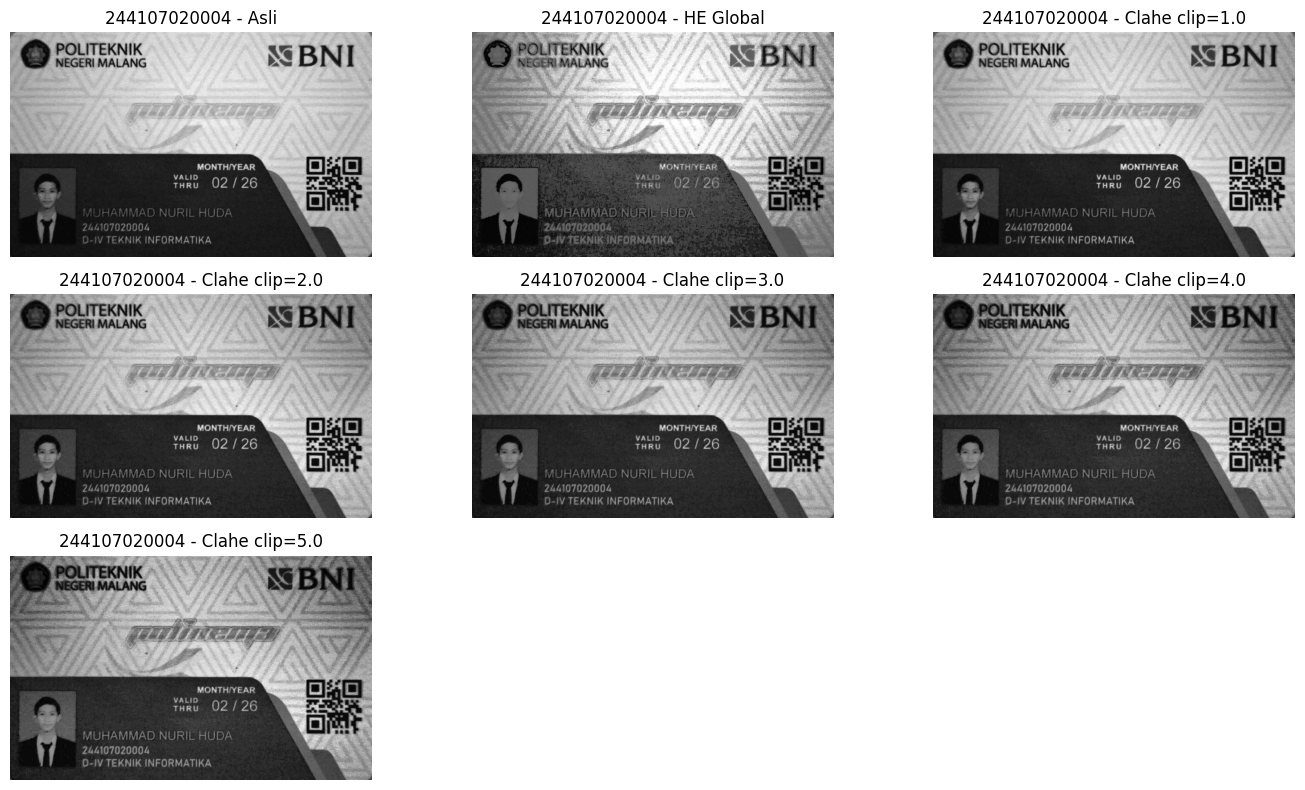

In [32]:
plt.figure(figsize=(14,8))

plt.subplot(3,3,1)
plt.imshow(ktm1a_gray, cmap='gray')
plt.title(NIM + ' - Asli')
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(ktm1a_gray_he_cv, cmap='gray')
plt.title(NIM + ' - HE Global')
plt.axis('off')

clips = [
    PARAM['clip'] - 2,
    PARAM['clip'] - 1,
    PARAM['clip'],
    PARAM['clip'] + 1,
    PARAM['clip'] + 2
    ]

for i, clip in enumerate(clips):

    clahe = cv.createCLAHE(
        clipLimit=clip,
        tileGridSize=(
            PARAM['tile'],
            PARAM['tile']
        )
    )

    hasil = clahe.apply(ktm1a_gray)

    plt.subplot(3,3,i+3)

    plt.imshow(hasil,cmap='gray')

    plt.title(NIM + ' - Clahe clip=' + str(clip))

    plt.axis('off')

plt.tight_layout()
plt.show()

Hasil CLAHE membuat NIM dan nama lebih mudah dibaca dibandingkan ekualisasi global. Nilai clipLimit = 1 menghasilkan tampilan terbaik karena tulisan terlihat jelas dan noise masih rendah. Saat clipLimit dinaikkan, noise mulai terlihat pada bagian-bagian gelap citra.